In [1]:
import numpy as np;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;
import gysela_utilities as utils;
import pandas as pd;

# Styling.
plt.style.use("ggplot");

In [2]:
# Test inputs - delete when done!
BASE_PATH = "/zhisongqu_data/seth/GYSELA/raw/fresh_batch_7.0";
PREFIX = "DN_DAYCASE_DELTASCAN_255X512_Q3.5";
effective_radius = 0.7
GAM_cutoff_frequencies = utils.convenience_parameters["GAM_cutoff_frequencies_template"];
df = utils.parameter_scan_analysis_phi2D(BASE_PATH, PREFIX, dt_diag = 50, effective_radius = effective_radius, cutoff_frequencies = GAM_cutoff_frequencies);
print(df);

Processing DN_DAYCASE_DELTASCAN_255X512_Q3.5_-0.1 with parameter value: -0.1
Processing DN_DAYCASE_DELTASCAN_255X512_Q3.5_-0.2 with parameter value: -0.2
Processing DN_DAYCASE_DELTASCAN_255X512_Q3.5_-0.3 with parameter value: -0.3
Processing DN_DAYCASE_DELTASCAN_255X512_Q3.5_0.0 with parameter value: 0.0
Processing DN_DAYCASE_DELTASCAN_255X512_Q3.5_0.1 with parameter value: 0.1
Processing DN_DAYCASE_DELTASCAN_255X512_Q3.5_0.2 with parameter value: 0.2
Processing DN_DAYCASE_DELTASCAN_255X512_Q3.5_0.3 with parameter value: 0.3
   parameter_value  gam_frequency  gam_growth_rate  \
2             -0.3       0.001530        -0.001516   
1             -0.2       0.001524        -0.001087   
0             -0.1       0.001530        -0.001676   
3              0.0       0.001535        -0.001866   
4              0.1       0.001540        -0.001307   
5              0.2       0.001551        -0.001411   
6              0.3       0.001567        -0.000887   

                              folder

<>:16: SyntaxWarning: invalid escape sequence '\g'
<>:23: SyntaxWarning: invalid escape sequence '\k'
<>:27: SyntaxWarning: invalid escape sequence '\d'
<>:16: SyntaxWarning: invalid escape sequence '\g'
<>:23: SyntaxWarning: invalid escape sequence '\k'
<>:27: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3694457/200545783.py:16: SyntaxWarning: invalid escape sequence '\g'
  damping_plot.set_ylabel("$\gamma$", color = damping_colour, fontsize = 12);
/tmp/ipykernel_3694457/200545783.py:23: SyntaxWarning: invalid escape sequence '\k'
  plt.title(f"GAM characteristics vs. {param_label}, $q = 3.5, \kappa = 1.0, \\rho = {effective_radius}$", fontsize = 14, pad = 20);
/tmp/ipykernel_3694457/200545783.py:27: SyntaxWarning: invalid escape sequence '\d'
  plot_parameter_scan_results(df, param_label=f"$\delta$");


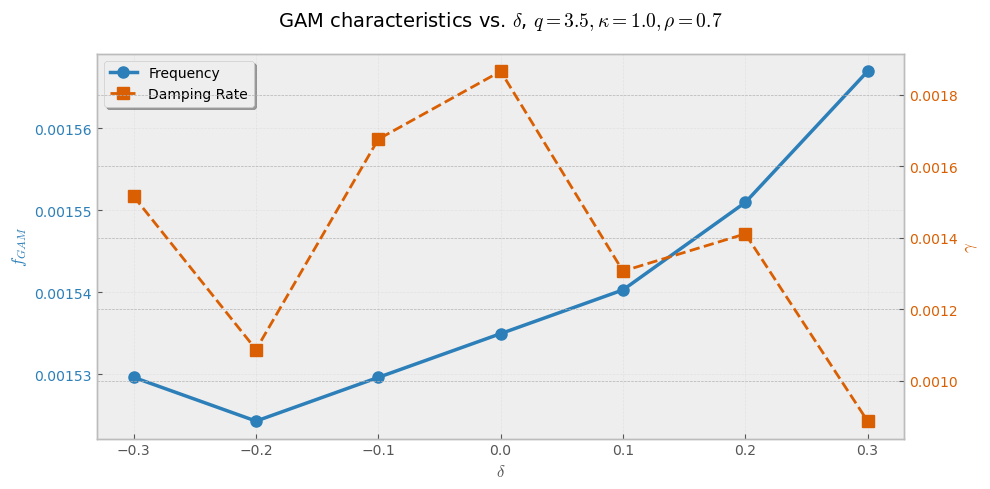

In [20]:
plt.style.use("bmh");

def plot_parameter_scan_results(df, param_label):

	canvas, frequency_plot = plt.subplots(figsize = (10, 5));

	frequency_colour = "#2c7fb8";
	frequency_plot.set_xlabel(param_label, fontsize = 12, fontweight = "bold");
	frequency_plot.set_ylabel('$f_{GAM}$', color = frequency_colour, fontsize = 12);
	frequency_line = frequency_plot.plot(df["parameter_value"], df["gam_frequency"], marker = "o", markersize = 8, color = frequency_colour, linewidth = 2.5, label = "Frequency");
	frequency_plot.tick_params(axis = "y", labelcolor = frequency_colour);
	frequency_plot.grid(True, linestyle = "--", alpha = 0.2);

	damping_plot = frequency_plot.twinx();
	damping_colour = "#d95f02";
	damping_plot.set_ylabel("$\gamma$", color = damping_colour, fontsize = 12);
	damping_line = damping_plot.plot(df["parameter_value"], np.abs(df["gam_growth_rate"]), marker = "s", markersize = 8, color = damping_colour, linestyle = '--', linewidth = 2, label = "Damping Rate");
	damping_plot.tick_params(axis='y', labelcolor = damping_colour);

	lines = frequency_line + damping_line;
	labels = [line.get_label() for line in lines];
	frequency_plot.legend(lines, labels, loc='upper left', frameon = True, shadow = True);
	plt.title(f"GAM characteristics vs. {param_label}, $q = 3.5, \kappa = 1.0, \\rho = {effective_radius}$", fontsize = 14, pad = 20);
	canvas.tight_layout();
	plt.show();

plot_parameter_scan_results(df, param_label=f"$\delta$");
